# Black-Scholes Pricing & Greeks

The Black-Scholes model is the foundation of modern options theory. Under geometric Brownian motion with constant volatility, it gives a closed-form formula for European option prices and — by differentiation — exact sensitivities to every market variable.

| Greek | Notation | Sensitivity to |
|-------|----------|----------------|
| Delta | Δ | Spot price |
| Gamma | Γ | Second-order spot (convexity) |
| Vega  | ν | Volatility |
| Theta | Θ | Time (daily decay) |
| Rho   | ρ | Risk-free rate |

---

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from src.black_scholes import (
    bs_price, delta, gamma, vega, theta, rho,
    numerical_delta, numerical_gamma, numerical_vega
)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Reference contract: ATM, 1-year, 20% vol, 5% rate
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
S_range = np.linspace(60, 140, 200)

## Step 1 — Option Price vs Spot

The call price grows monotonically with spot (unlimited upside) while the put price falls. Both converge to their intrinsic values when deep in-the-money. The gap between the two reflects time value: the present value of the possibility that the option finishes in-the-money.

**Put-call parity:** `C − P = S − K·e^(−rT)` must hold for all strikes, or there is an arbitrage.

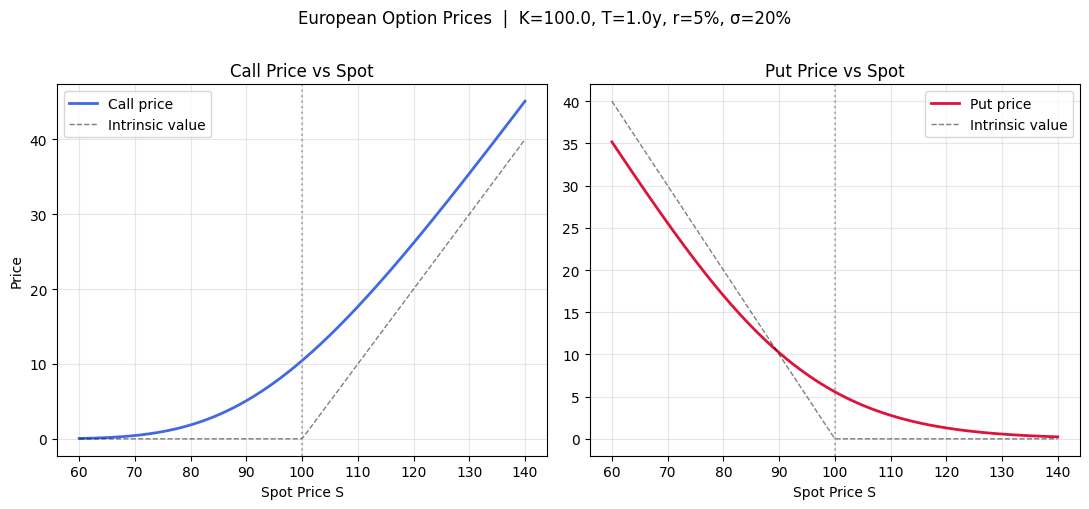

In [2]:
call_prices = [bs_price(S, K, T, r, sigma, 'call') for S in S_range]
put_prices  = [bs_price(S, K, T, r, sigma, 'put')  for S in S_range]
intrinsic_c = np.maximum(S_range - K, 0)
intrinsic_p = np.maximum(K - S_range, 0)

fig, axes = plt.subplots(1, 2)
axes[0].plot(S_range, call_prices, 'royalblue', lw=2, label='Call price')
axes[0].plot(S_range, intrinsic_c, 'k--', lw=1, alpha=0.5, label='Intrinsic value')
axes[0].axvline(K, color='gray', linestyle=':', alpha=0.6)
axes[0].set_title('Call Price vs Spot')
axes[0].set_xlabel('Spot Price S')
axes[0].set_ylabel('Price')
axes[0].legend()

axes[1].plot(S_range, put_prices, 'crimson', lw=2, label='Put price')
axes[1].plot(S_range, intrinsic_p, 'k--', lw=1, alpha=0.5, label='Intrinsic value')
axes[1].axvline(K, color='gray', linestyle=':', alpha=0.6)
axes[1].set_title('Put Price vs Spot')
axes[1].set_xlabel('Spot Price S')
axes[1].legend()

plt.suptitle(f'European Option Prices  |  K={K}, T={T}y, r={r:.0%}, σ={sigma:.0%}', y=1.01)
plt.tight_layout()
plt.show()

## Step 2 — Put-Call Parity Verification

For any European option under no-arbitrage: `C − P = S − K·e^(−rT)`. The left side is the market spread; the right side is the forward minus PV(strike). If these differ, risk-free profit is possible.

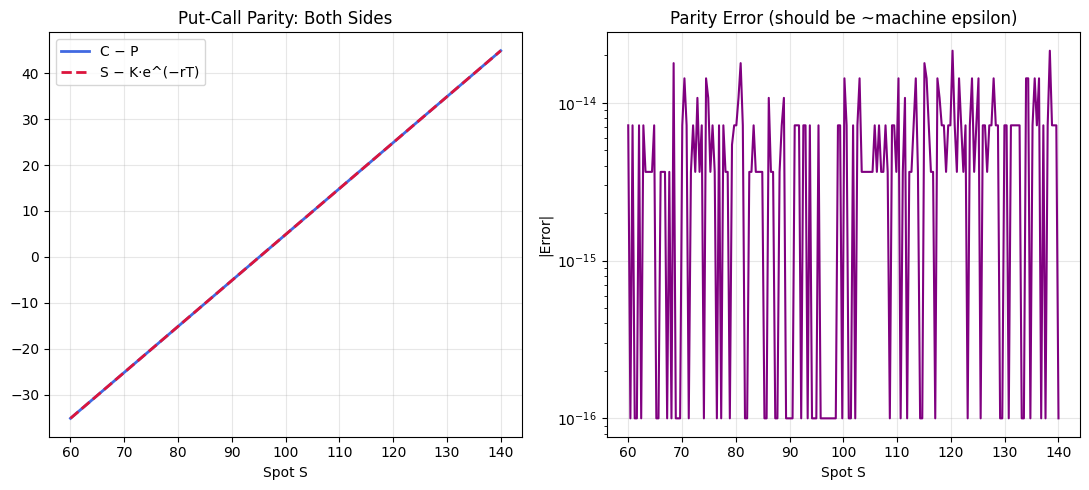

Max absolute parity error: 2.13e-14


In [3]:
lhs = np.array(call_prices) - np.array(put_prices)
rhs = S_range - K * np.exp(-r * T)
error = np.abs(lhs - rhs)

fig, axes = plt.subplots(1, 2)
axes[0].plot(S_range, lhs, 'royalblue', lw=2, label='C − P')
axes[0].plot(S_range, rhs, 'crimson', lw=2, linestyle='--', label='S − K·e^(−rT)')
axes[0].set_title('Put-Call Parity: Both Sides')
axes[0].set_xlabel('Spot S')
axes[0].legend()

axes[1].semilogy(S_range, error + 1e-16, 'purple', lw=1.5)
axes[1].set_title('Parity Error (should be ~machine epsilon)')
axes[1].set_xlabel('Spot S')
axes[1].set_ylabel('|Error|')

plt.tight_layout()
plt.show()
print(f'Max absolute parity error: {error.max():.2e}')

## Step 3 — Delta: First-Order Spot Sensitivity

Delta is the hedge ratio: a portfolio of Δ shares per long call is instantaneously delta-neutral. Call delta ∈ (0,1) and put delta ∈ (−1,0). Both are N(d₁) under the standard parameterisation — deep ITM call → Δ≈1, deep OTM call → Δ≈0.

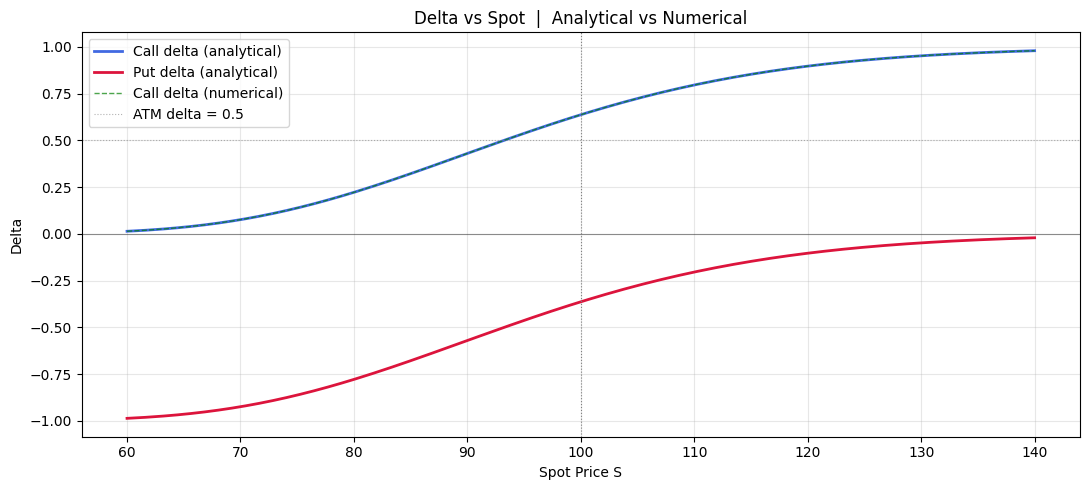

In [4]:
call_delta = [delta(S, K, T, r, sigma, 'call') for S in S_range]
put_delta  = [delta(S, K, T, r, sigma, 'put')  for S in S_range]
num_delta  = [numerical_delta(S, K, T, r, sigma, 'call') for S in S_range]

fig, ax = plt.subplots()
ax.plot(S_range, call_delta, 'royalblue', lw=2, label='Call delta (analytical)')
ax.plot(S_range, put_delta,  'crimson',   lw=2, label='Put delta (analytical)')
ax.plot(S_range, num_delta,  'green', lw=1, linestyle='--', alpha=0.7, label='Call delta (numerical)')
ax.axhline(0,   color='black', linewidth=0.8, alpha=0.4)
ax.axhline(0.5, color='gray',  linewidth=0.8, linestyle=':', alpha=0.6, label='ATM delta = 0.5')
ax.axvline(K,   color='gray',  linewidth=0.8, linestyle=':')
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Spot  |  Analytical vs Numerical')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Gamma: Convexity / Second-Order Spot Sensitivity

Gamma is the rate of change of delta — identical for calls and puts (put-call parity). It peaks at-the-money and for short-dated options. High gamma means the delta hedge must be rebalanced frequently. Gamma is always positive for long options (beneficial convexity).

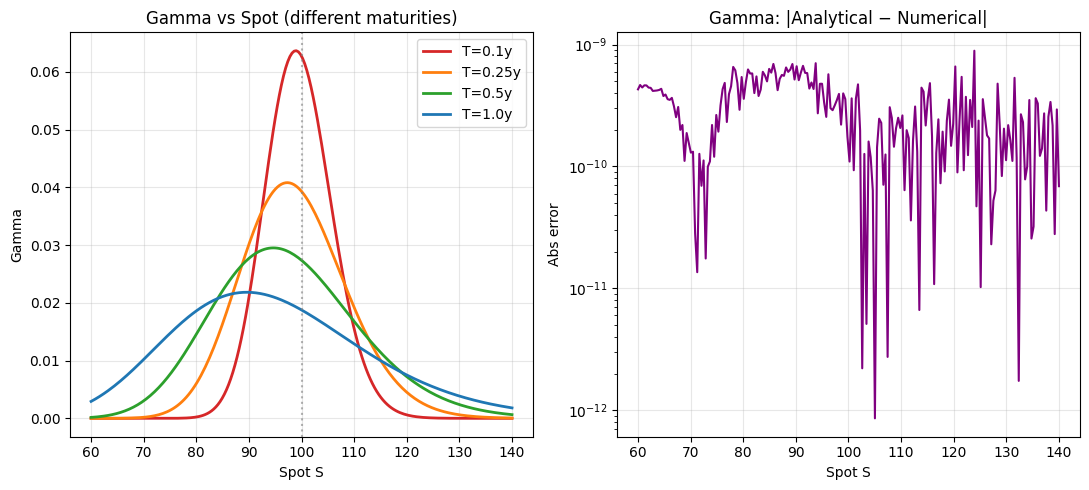

In [5]:
T_values = [0.1, 0.25, 0.5, 1.0]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

fig, axes = plt.subplots(1, 2)
for T_val, col in zip(T_values, colors):
    g_vals = [gamma(S, K, T_val, r, sigma) for S in S_range]
    axes[0].plot(S_range, g_vals, color=col, lw=2, label=f'T={T_val}y')

axes[0].axvline(K, color='gray', linestyle=':', alpha=0.6)
axes[0].set_xlabel('Spot S')
axes[0].set_ylabel('Gamma')
axes[0].set_title('Gamma vs Spot (different maturities)')
axes[0].legend()

num_gamma_vals = [numerical_gamma(S, K, T, r, sigma) for S in S_range]
ana_gamma_vals = [gamma(S, K, T, r, sigma) for S in S_range]
err = np.abs(np.array(ana_gamma_vals) - np.array(num_gamma_vals))
axes[1].semilogy(S_range, err + 1e-16, 'purple', lw=1.5)
axes[1].set_title('Gamma: |Analytical − Numerical|')
axes[1].set_xlabel('Spot S')
axes[1].set_ylabel('Abs error')

plt.tight_layout()
plt.show()

## Step 5 — Vega: Volatility Sensitivity

Vega is identical for calls and puts (again, put-call parity). It peaks ATM and at longer maturities. All else equal, higher vol → higher option price because it increases the probability of a larger terminal payoff. Reported here per 1% change in vol (100 bp).

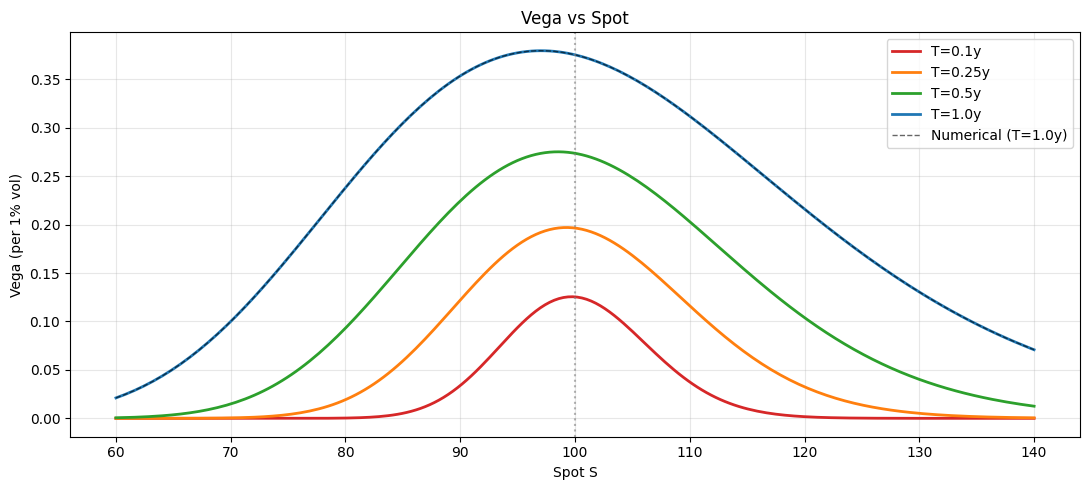

In [6]:
fig, ax = plt.subplots()
for T_val, col in zip(T_values, colors):
    v_vals = [vega(S, K, T_val, r, sigma) for S in S_range]
    ax.plot(S_range, v_vals, color=col, lw=2, label=f'T={T_val}y')

nv = [numerical_vega(S, K, T, r, sigma) for S in S_range]
ax.plot(S_range, nv, 'k--', lw=1, alpha=0.6, label=f'Numerical (T={T}y)')
ax.axvline(K, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Spot S')
ax.set_ylabel('Vega (per 1% vol)')
ax.set_title('Vega vs Spot')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 — Theta: Time Decay

Theta is almost always negative for long options (time erodes option value). The call theta is less negative than the put because the call benefits from the time value of the strike PV (positive rho effect). Near expiry, theta accelerates sharply for ATM options.

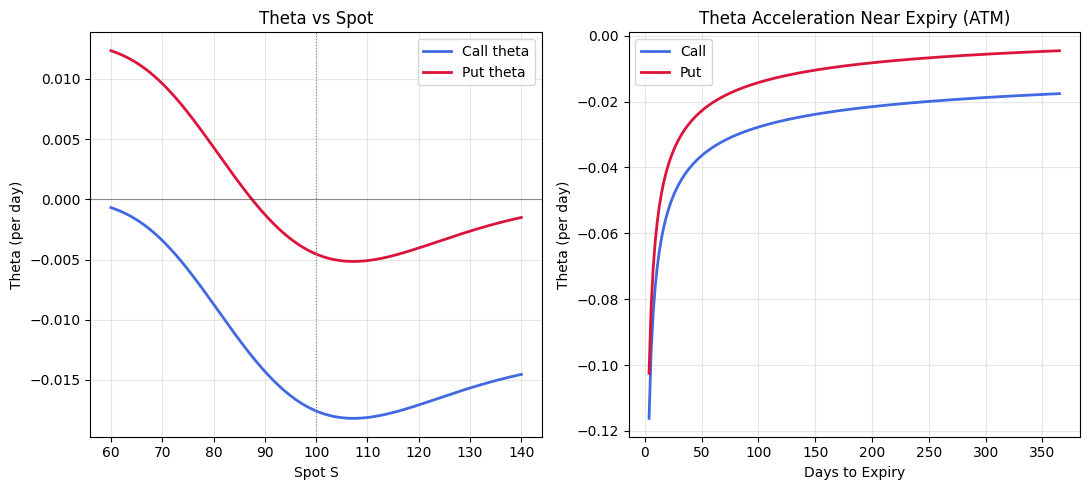

In [7]:
call_theta = [theta(S, K, T, r, sigma, 'call') for S in S_range]
put_theta  = [theta(S, K, T, r, sigma, 'put')  for S in S_range]

fig, axes = plt.subplots(1, 2)
axes[0].plot(S_range, call_theta, 'royalblue', lw=2, label='Call theta')
axes[0].plot(S_range, put_theta,  'crimson',   lw=2, label='Put theta')
axes[0].axhline(0, color='black', lw=0.8, alpha=0.4)
axes[0].axvline(K, color='gray',  lw=0.8, linestyle=':')
axes[0].set_xlabel('Spot S')
axes[0].set_ylabel('Theta (per day)')
axes[0].set_title('Theta vs Spot')
axes[0].legend()

T_near_range = np.linspace(0.01, 1.0, 200)
call_theta_t = [theta(S0, K, t, r, sigma, 'call') for t in T_near_range]
put_theta_t  = [theta(S0, K, t, r, sigma, 'put')  for t in T_near_range]
axes[1].plot(T_near_range * 365, call_theta_t, 'royalblue', lw=2, label='Call')
axes[1].plot(T_near_range * 365, put_theta_t,  'crimson',   lw=2, label='Put')
axes[1].set_xlabel('Days to Expiry')
axes[1].set_ylabel('Theta (per day)')
axes[1].set_title('Theta Acceleration Near Expiry (ATM)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 7 — Rho: Rate Sensitivity

Rho is positive for calls (higher rates → call more valuable, as holding the call replaces buying the stock at the PV of strike) and negative for puts. Rho is less important for short-dated options but meaningful for LEAPS. Reported per 1% change in rate (100 bp).

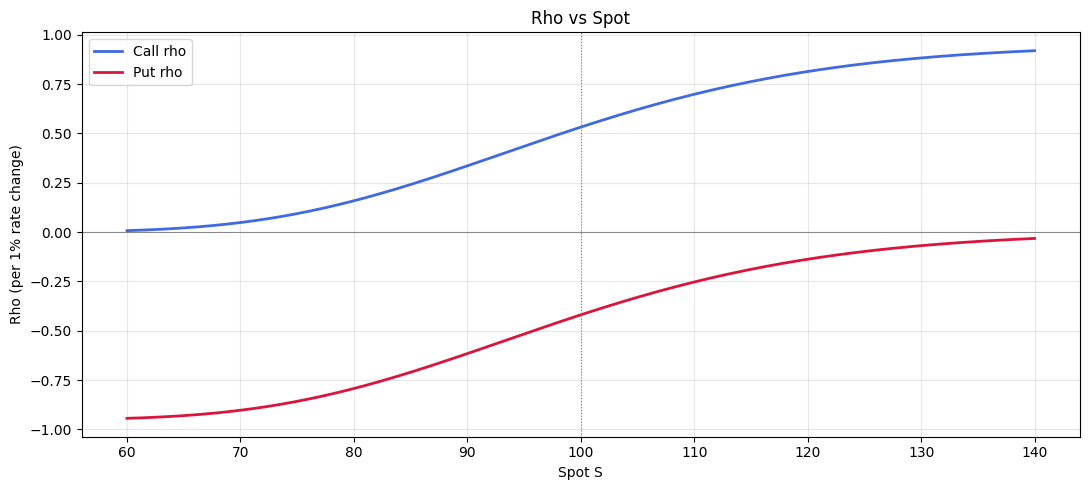

In [8]:
call_rho = [rho(S, K, T, r, sigma, 'call') for S in S_range]
put_rho  = [rho(S, K, T, r, sigma, 'put')  for S in S_range]

fig, ax = plt.subplots()
ax.plot(S_range, call_rho, 'royalblue', lw=2, label='Call rho')
ax.plot(S_range, put_rho,  'crimson',   lw=2, label='Put rho')
ax.axhline(0, color='black', lw=0.8, alpha=0.4)
ax.axvline(K, color='gray',  lw=0.8, linestyle=':')
ax.set_xlabel('Spot S')
ax.set_ylabel('Rho (per 1% rate change)')
ax.set_title('Rho vs Spot')
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — 3D Greek Surfaces over (S, σ)

Each Greek is a function of all inputs simultaneously. Visualising over the (spot, volatility) plane reveals how sensitivities interact — for example, how gamma for short-dated options becomes a spike at ATM as vol decreases.

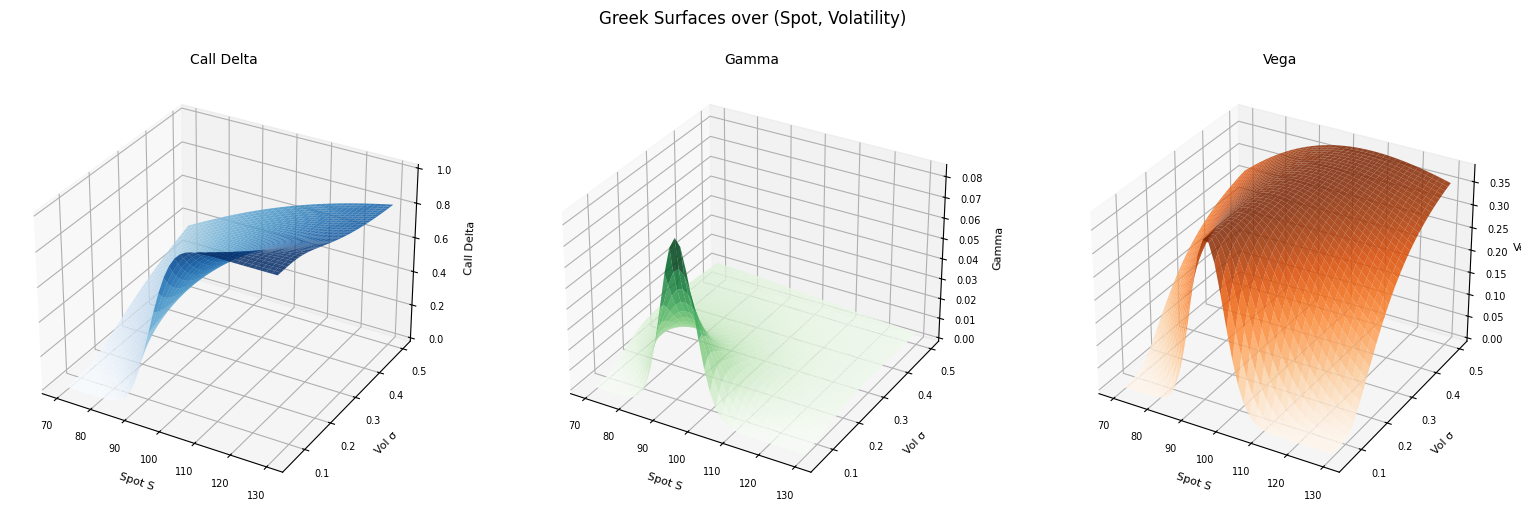

In [9]:
S_grid = np.linspace(70, 130, 40)
sigma_grid = np.linspace(0.05, 0.50, 40)
SS, SIG = np.meshgrid(S_grid, sigma_grid)

delta_surf = np.vectorize(lambda s, sig: delta(s, K, T, r, sig, 'call'))(SS, SIG)
gamma_surf = np.vectorize(lambda s, sig: gamma(s, K, T, r, sig))(SS, SIG)
vega_surf  = np.vectorize(lambda s, sig: vega(s, K, T, r, sig))(SS, SIG)

fig = plt.figure(figsize=(16, 5))
for idx, (surf, title, cmap) in enumerate([
    (delta_surf, 'Call Delta', 'Blues'),
    (gamma_surf, 'Gamma',      'Greens'),
    (vega_surf,  'Vega',       'Oranges')
]):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.plot_surface(SS, SIG, surf, cmap=cmap, alpha=0.85, linewidth=0)
    ax.set_xlabel('Spot S', fontsize=8)
    ax.set_ylabel('Vol σ', fontsize=8)
    ax.set_zlabel(title, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7)

plt.suptitle('Greek Surfaces over (Spot, Volatility)', y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Analytical vs Numerical Cross-Check

Finite-difference Greeks (central differences with tiny ε) should match the analytical formulas to within floating-point precision. This confirms the code is internally consistent.

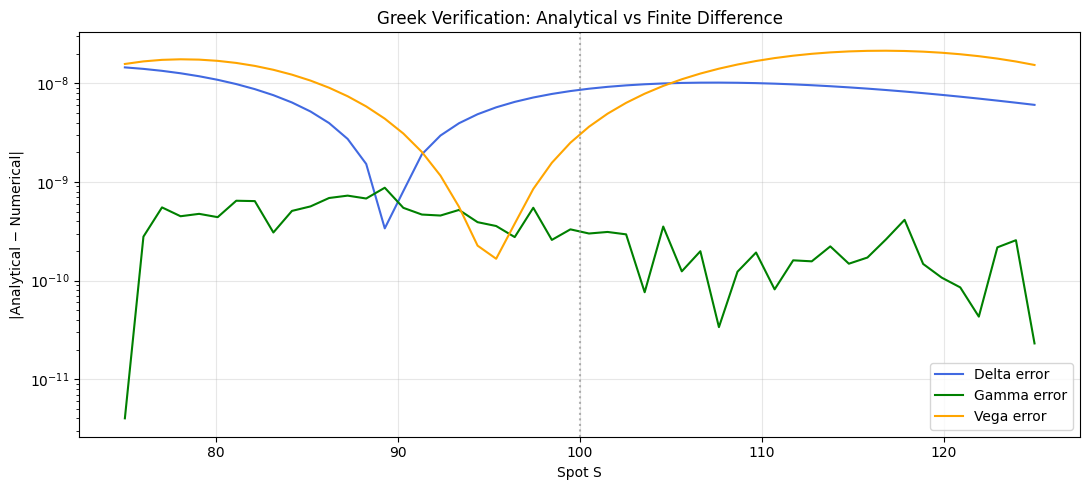

Max delta error: 1.45e-08
Max gamma error: 8.75e-10
Max vega error:  2.14e-08


In [10]:
test_spots = np.linspace(75, 125, 50)

err_delta = [abs(delta(S, K, T, r, sigma, 'call') - numerical_delta(S, K, T, r, sigma, 'call')) for S in test_spots]
err_gamma = [abs(gamma(S, K, T, r, sigma)          - numerical_gamma(S, K, T, r, sigma))          for S in test_spots]
err_vega  = [abs(vega(S, K, T, r, sigma)            - numerical_vega(S, K, T, r, sigma))            for S in test_spots]

fig, ax = plt.subplots()
ax.semilogy(test_spots, err_delta, 'royalblue', lw=1.5, label='Delta error')
ax.semilogy(test_spots, err_gamma, 'green',     lw=1.5, label='Gamma error')
ax.semilogy(test_spots, err_vega,  'orange',    lw=1.5, label='Vega error')
ax.axvline(K, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Spot S')
ax.set_ylabel('|Analytical − Numerical|')
ax.set_title('Greek Verification: Analytical vs Finite Difference')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Max delta error: {max(err_delta):.2e}')
print(f'Max gamma error: {max(err_gamma):.2e}')
print(f'Max vega error:  {max(err_vega):.2e}')